In [26]:
### === IMPORTS === ###
import sys
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import make_scorer
import statsmodels.api as sm
from sklearn.model_selection import ParameterGrid
import matplotlib.colors as mcolors

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Data Preprocessing

In [27]:
### === PREPROCESSED DATA LODA === ###
EDA_DIR = Path.cwd()  # should be .../<parent folder name>/eda
PROJECT_ROOT = EDA_DIR.parent # .../<parent folder name>
STATSBOMB_DIR = PROJECT_ROOT / "data"

BUCKETS_PATH = STATSBOMB_DIR / "df_all_buckets.csv"
df_all_buckets = pd.read_csv(BUCKETS_PATH)

print("df_all_buckets shape :", df_all_buckets.shape)

df_all_buckets shape : (34668, 43)


In [28]:
df_all_buckets[(df_all_buckets['match_id']==7580) & ((df_all_buckets['total_minutes']==15) | (df_all_buckets['total_minutes']==90))]

,match_id,team,opponent,year,total_minutes,result,win,goals_scored,goals_conceded,goal_diff,goals_scored_timebucket,goals_conceded_timebucket,goal_diff_timebucket,shots,shots_on_target,xg_for,final_third_entries,final_third_passes,final_third_carries,pressures,shots_against,sot_against,xg_against,final_third_against,pressure_against,shot_diff,sot_diff,xg_diff,final_third_diff,pressure_diff,n_carries,n_dribbles,n_passes,n_passes_complete,pass_completion_rate,carries_against,dribbles_against,passes_against,passes_complete_against,carry_diff,dribble_diff,pass_diff,pass_complete_diff
98,7580,Argentina,France,2018,15,Loss,0.0,3,4,-1,0,1,-1,0,0,0.000000,56,33,23,30,2,1,0.849040,12,56,-2,-1,-0.849040,44,-26,97,1,108,93,0.861111,41,3,44,30,56,-2,64,63
99,7580,France,Argentina,2018,15,Win,1.0,4,3,1,1,0,1,2,1,0.849040,12,6,6,56,0,0,0.000000,56,30,2,1,0.849040,-44,26,41,3,44,30,0.681818,97,1,108,93,-56,2,-64,-63
28988,7580,Argentina,France,2018,90,Loss,0.0,3,4,-1,3,4,-1,12,4,1.446559,326,179,147,180,9,4,1.638027,138,281,3,0,-0.191468,188,-101,491,22,535,448,0.837383,333,15,350,283,158,7,185,165
28989,7580,France,Argentina,2018,90,Win,1.0,4,3,1,4,3,1,9,4,1.638027,138,72,66,281,12,4,1.446559,326,180,-3,0,0.191468,-188,101,333,15,350,283,0.808571,491,22,535,448,-158,-7,-185,-165


<br>
<br>
<br>
<br>

# Correlation Analysis (90 minutes)
---

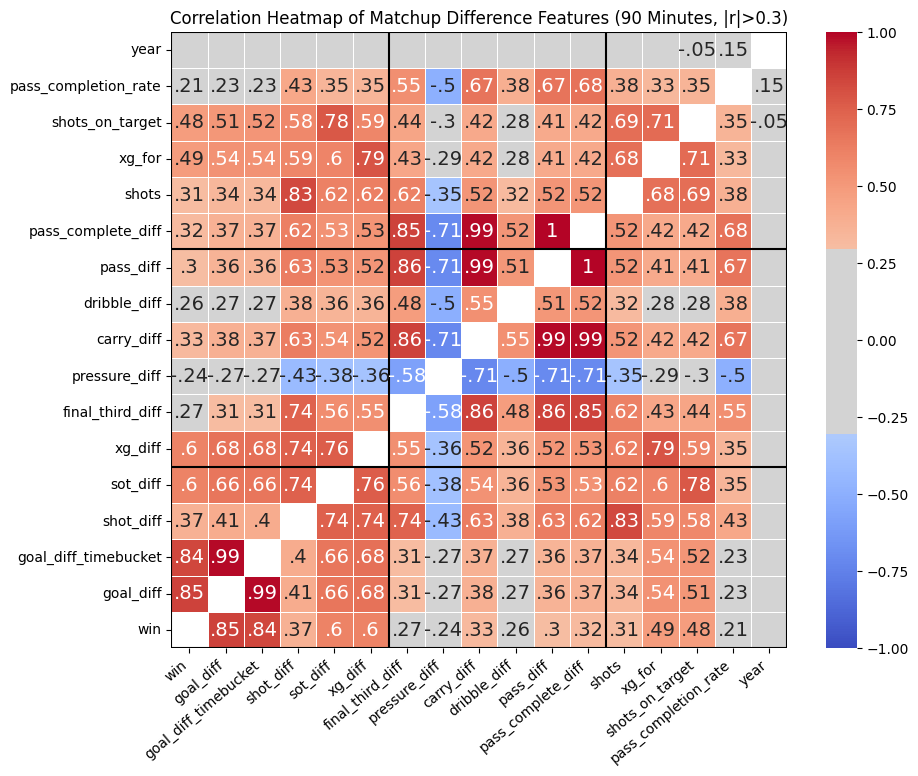

In [29]:
df_90 = df_all_buckets[df_all_buckets['total_minutes'] == 90]

# Select only key features (Diff features + select others)
corr_cols = [c for c in df_90.columns if c.endswith("_diff")]
corr_cols.insert(0, 'win')
corr_cols.insert(2, 'goal_diff_timebucket')
corr_cols = corr_cols + ['shots', 'xg_for', 'shots_on_target', 'pass_completion_rate', 'year']

corr = df_90[corr_cols].corr()
corr_no_diag = corr.where(~np.eye(corr.shape[0], dtype=bool)) # remove diagonal

# remove diagonal only, reverse y-axis labels
corr_no_diag = corr.where(~np.eye(corr.shape[0], dtype=bool)) # remove diagonal
corr_no_diag = corr_no_diag.iloc[::-1] # reverse y-axis labels only

### Custom colormap with grey band for [-0.3, 0.3] ###
base_cmap = plt.get_cmap('coolwarm')
colors = base_cmap(np.linspace(0, 1, 256))                    # 1. Base colormap
lower_bound = int(0.35 * 256)
upper_bound = int(0.65 * 256)                                 # 2. Define grey band
colors[lower_bound:upper_bound] = mcolors.to_rgba('#d3d3d3')
custom_coolwarm = mcolors.ListedColormap(colors)
annot = corr_no_diag.map(                                  # 3. Clean annotations (only strong correlations)
    lambda x: (f"{x:.2f}".rstrip("0").rstrip(".").replace("-0.", "-.").lstrip("0")if pd.notnull(x) and abs(x) > 0.009 else ""))

plt.figure(figsize=(10,8))
# sns.set(font_scale=1.4)

ax = sns.heatmap(
    corr_no_diag,
    annot=annot,
    fmt="",
    cmap=custom_coolwarm,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 14},
    cbar=True
)

# Add thicker grid lines every 6 features
n = corr_no_diag.shape[0]
for i in range(0, n, 6):
    ax.hlines(i, *ax.get_xlim(), colors='black', linewidth=1.5)
    ax.vlines(i, *ax.get_ylim(), colors='black', linewidth=1.5)
ax.hlines(n, *ax.get_xlim(), colors='black', linewidth=1.5)
ax.vlines(n, *ax.get_ylim(), colors='black', linewidth=1.5)

plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of Matchup Difference Features (90 Minutes, |r|>0.3)")
plt.savefig(PROJECT_ROOT / "Images" / "corr_heatmap_90.png", dpi=300, bbox_inches='tight')
plt.show()
# sns.set(font_scale=1)

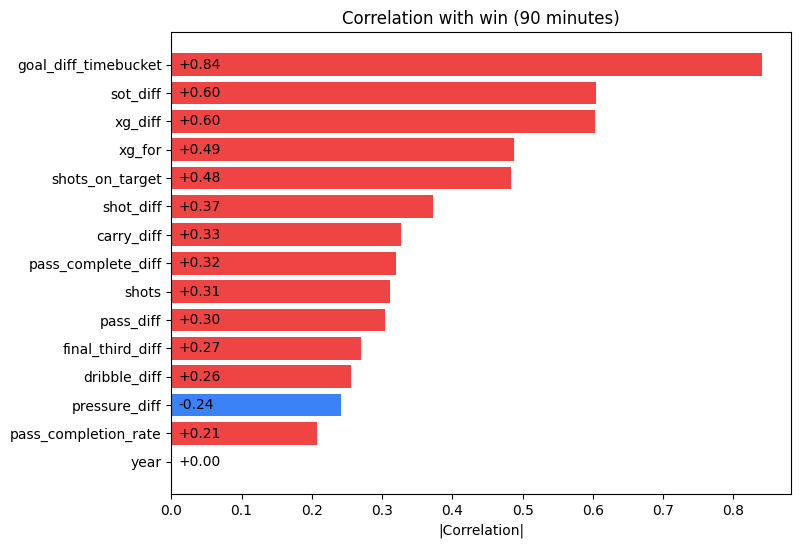

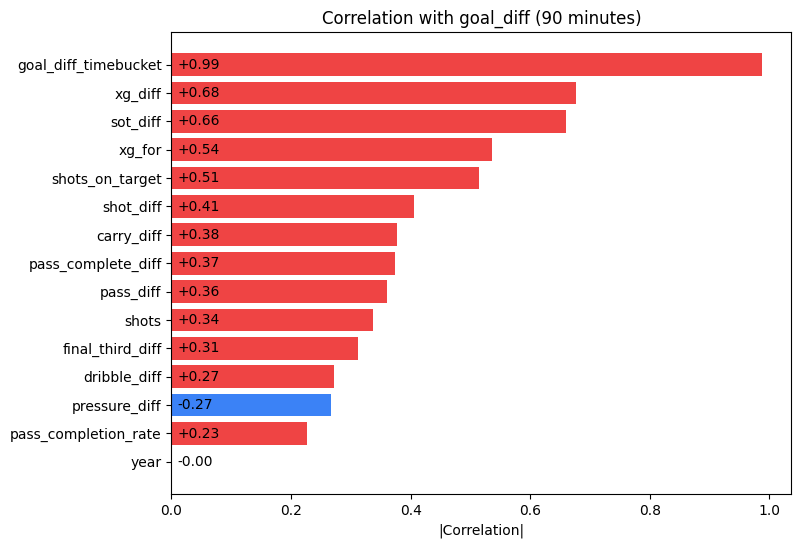

In [30]:
targets = ["win", "goal_diff"]

drop_map = {}

base_drop = set(targets)
# sns.set(font_scale=1)

for t in targets:
    to_drop = base_drop
    corr_target = (
        corr[t]
        .drop(labels=list(to_drop), errors="ignore")
    )

    # sort by absolute correlation
    corr_target = corr_target.reindex(
        corr_target.abs().sort_values().index
    )
    # print(corr_target.abs().sort_values().index)

    values = corr_target.values
    abs_vals = np.abs(values)

    colors = ["#ef4444" if v > 0 else "#3b82f6" for v in values]

    fig, ax = plt.subplots(figsize=(8,6))

    bars = ax.barh(
        corr_target.index,
        abs_vals,
        color=colors
    )
    
    # sns.set(font_scale=1.4)
    ax.set_title(f"Correlation with {t} (90 minutes)")
    ax.set_xlabel("|Correlation|")

    # add signed labels
    for bar, val in zip(bars, values):
        ax.text(
            0.01,
            bar.get_y() + bar.get_height()/2,
            f"{val:+.2f}",
            va="center",
            # ha="left" if width > 0 else "right",
            # fontsize=20
        )
    plt.savefig(PROJECT_ROOT / "Images" / f"corr_bars_{t}_90", dpi=300, bbox_inches='tight')
    plt.show()

# sns.set_theme() # back to default font_scale=1

<br>
<br>
<br>
<br>

# Correlation Analysis (45 minutes)
---

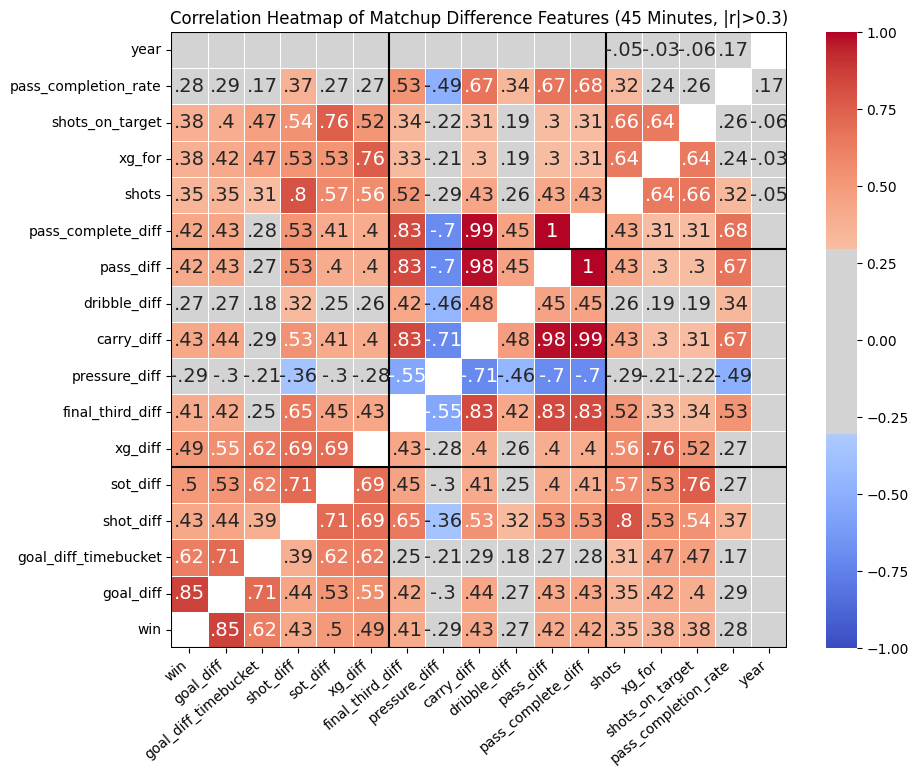

In [31]:
df_45 = df_all_buckets[df_all_buckets['total_minutes'] == 45]

corr_45 = df_45[corr_cols].corr()

# remove diagonal only, reverse y-axis labels
corr_no_diag_45 = corr_45.where(~np.eye(corr_45.shape[0], dtype=bool)) # remove diagonal
corr_no_diag_45 = corr_no_diag_45.iloc[::-1] # reverse y-axis labels only

### Custom colormap with grey band for [-0.3, 0.3] ###
base_cmap = plt.get_cmap('coolwarm')
colors = base_cmap(np.linspace(0, 1, 256))                    # 1. Base colormap
lower_bound = int(0.35 * 256)
upper_bound = int(0.65 * 256)                                 # 2. Define grey band
colors[lower_bound:upper_bound] = mcolors.to_rgba('#d3d3d3')
custom_coolwarm = mcolors.ListedColormap(colors)
annot = corr_no_diag_45.map(                                  # 3. Clean annotations (only strong correlations)
    lambda x: (f"{x:.2f}".rstrip("0").rstrip(".").replace("-0.", "-.").lstrip("0")if pd.notnull(x) and abs(x) > 0.009 else ""))

plt.figure(figsize=(10,8))
# sns.set(font_scale=1.4)

ax = sns.heatmap(
    corr_no_diag_45,
    annot=annot,
    fmt="",
    cmap=custom_coolwarm,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 14},
    cbar=True
)

# Add thicker grid lines every 6 features
n = corr_no_diag_45.shape[0]
for i in range(0, n, 6):
    ax.hlines(i, *ax.get_xlim(), colors='black', linewidth=1.5)
    ax.vlines(i, *ax.get_ylim(), colors='black', linewidth=1.5)
ax.hlines(n, *ax.get_xlim(), colors='black', linewidth=1.5)
ax.vlines(n, *ax.get_ylim(), colors='black', linewidth=1.5)

plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of Matchup Difference Features (45 Minutes, |r|>0.3)")

plt.savefig(PROJECT_ROOT / "Images" / "corr_heatmap_45.png", dpi=300, bbox_inches='tight')
plt.show()
# sns.set(font_scale=1)

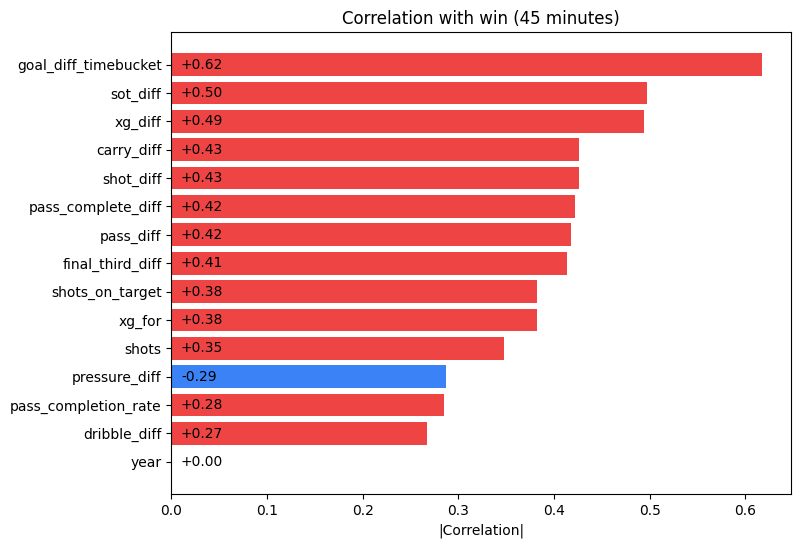

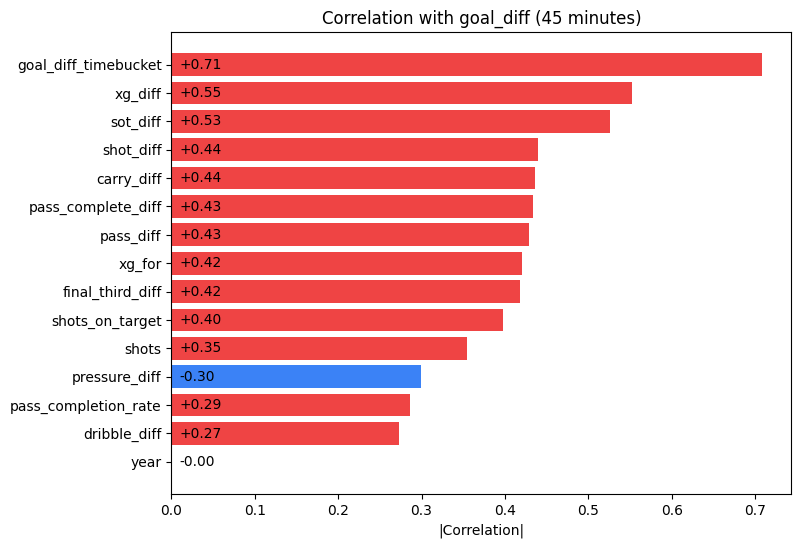

In [32]:
targets = ["win", "goal_diff"]

drop_map = {}

base_drop = set(targets)
# sns.set(font_scale=1)

for t in targets:
    to_drop = base_drop
    corr_target_45 = (
        corr_45[t]
        .drop(labels=list(to_drop), errors="ignore")
    )

    # sort by absolute correlation
    corr_target_45 = corr_target_45.reindex(
        corr_target_45.abs().sort_values().index
    )
    # print(corr_target_45.abs().sort_values().index)

    values = corr_target_45.values
    abs_vals = np.abs(values)

    colors = ["#ef4444" if v > 0 else "#3b82f6" for v in values]

    fig, ax = plt.subplots(figsize=(8,6))

    bars = ax.barh(
        corr_target_45.index,
        abs_vals,
        color=colors
    )
    
    # sns.set(font_scale=1.4)
    ax.set_title(f"Correlation with {t} (45 minutes)")
    ax.set_xlabel("|Correlation|")

    # add signed labels
    for bar, val in zip(bars, values):
        ax.text(
            0.01,
            bar.get_y() + bar.get_height()/2,
            f"{val:+.2f}",
            va="center",
            # ha="left" if width > 0 else "right",
            # fontsize=20
        )
    plt.savefig(PROJECT_ROOT / "Images" / f"corr_bars_{t}_45", dpi=300, bbox_inches='tight')
    plt.show()

# sns.set_theme() # back to default font_scale=1

<br>
<br>
<br>
<br>

# Correlation Difference (90min - 45min)
---

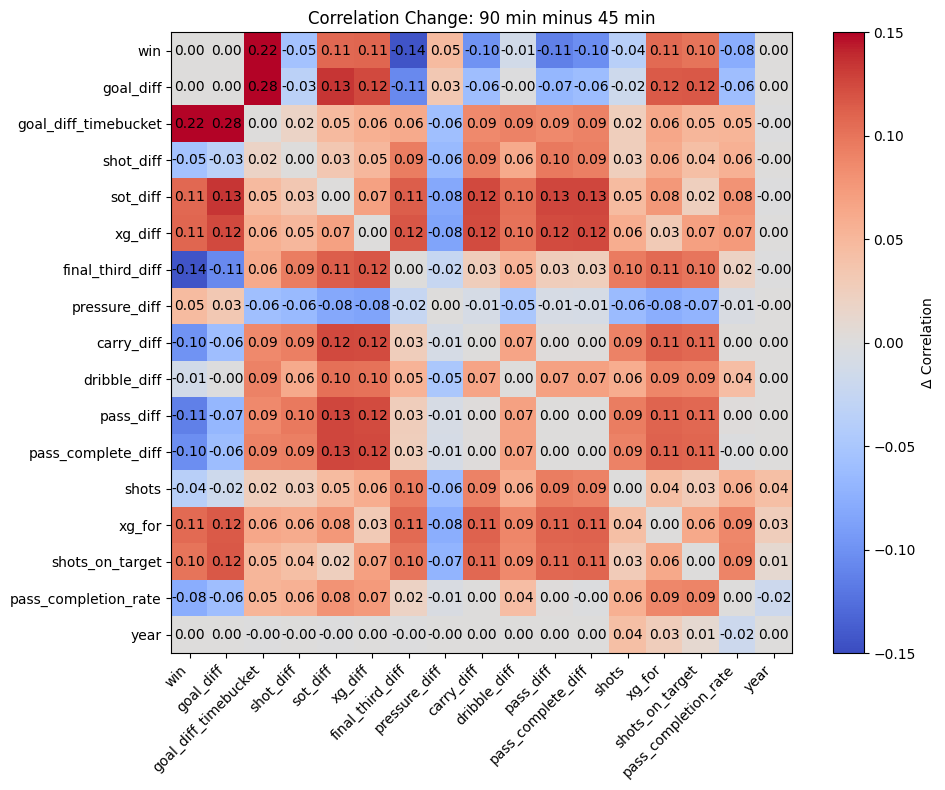

In [33]:
# elementwise difference
corr_diff = corr - corr_45

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr_diff, cmap="coolwarm", vmin=-0.15, vmax=0.15)

# ticks / labels
ax.set_xticks(np.arange(len(corr_diff.columns)))
ax.set_yticks(np.arange(len(corr_diff.index)))
ax.set_xticklabels(corr_diff.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_diff.index)

# annotate values
for i in range(corr_diff.shape[0]):
    for j in range(corr_diff.shape[1]):
        ax.text(j, i, f"{corr_diff.iloc[i, j]:.2f}", ha="center", va="center")


ax.set_title("Correlation Change: 90 min minus 45 min")
fig.colorbar(im, ax=ax, label="Δ Correlation")

plt.tight_layout()
plt.show()

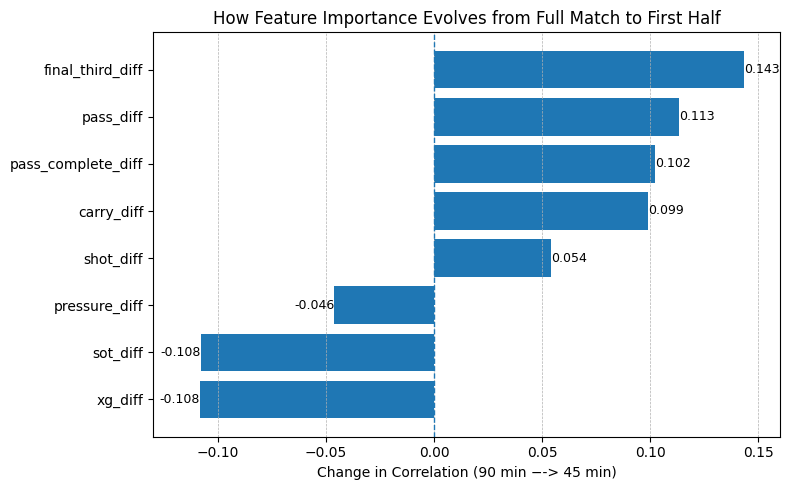

In [34]:
# choose the row/column you care most about
target = "win"
features = ["sot_diff", "xg_diff", "carry_diff", "shot_diff", "pass_complete_diff", "pass_diff", "final_third_diff", "pressure_diff"]

# compute deltas
delta = corr_45.loc[target, features] - corr.loc[target, features]

# sort by magnitude (optional but recommended)
delta = delta.sort_values()

# plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(delta.index, delta.values)

ax.set_xlabel("Change in Correlation (90 min −-> 45 min)")
ax.set_xlim(-0.13, 0.16)
ax.set_title("How Feature Importance Evolves from Full Match to First Half")

ax.axvline(0, linestyle="--", linewidth=1)  # zero reference line
ax.grid(True, axis="x", linestyle="--", linewidth=0.5)

# data labels
for i, v in enumerate(delta.values):
    ax.text(v, i, f"{v:.3f}", va="center", ha="left" if v > 0 else "right", fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "Images" / "corr_changes_45_90.png", dpi=300, bbox_inches='tight')
plt.show()

<br>
<br>
<br>
<br>

# Modeling
---

## BIC Forward Search (Additional Feature Selection Analysis)
---

In [35]:
### fit_logit_bic() and forward_stepwise_bic() ###
def fit_logit_bic(df, features, y_col="win"):
    """
    Fit logistic regression via statsmodels and return model + BIC.
    Draws (missing win) are removed automatically.
    """
    model_df = df.loc[df[y_col].notna()].copy()

    X = model_df[features].copy()
    X = sm.add_constant(X, has_constant="add")
    y = model_df[y_col].astype(int)

    model = sm.Logit(y, X).fit(disp=0)
    return model, model.bic


def forward_stepwise_bic(
    df,
    candidate_features,
    y_col="win",
    forced_features=None,
    verbose=True,
    prints=True
):
    """
    Forward stepwise feature selection using BIC for logistic regression.

    Parameters
    ----------
    df : pandas.DataFrame
        Training dataframe
    candidate_features : list[str]
        Candidate predictor columns
    y_col : str, default="win"
        Binary target column
    forced_features : list[str] or None
        Features forced into the model before forward search starts
    verbose : bool, default=True
        Whether to print stepwise progress

    Returns
    -------
    dict with:
        selected_features
        history
        model
        bic
    """

    # ----------------------------------------
    # 1. Clean setup
    # ----------------------------------------
    model_df = df.loc[df[y_col].notna()].copy()

    if forced_features is None:
        forced_features = []

    selected = forced_features.copy()
    remaining = [f for f in candidate_features if f not in selected]
    history = []

    # ----------------------------------------
    # 2. Initialize BIC
    # ----------------------------------------
    if len(selected) > 0:
        try:
            current_model, current_bic = fit_logit_bic(model_df, selected, y_col=y_col)
            history.append({
                "Step": 0,
                "Added": "FORCED",
                "BIC": current_bic,
                "Selected Features": selected.copy()
            })
            if verbose and prints:
                print(f"Forced features: {selected} | Starting BIC = {current_bic:.2f}")
        except Exception as e:
            raise ValueError(f"Could not fit forced-features model. Error: {e}")
    else:
        current_model = None
        current_bic = np.inf

    # ----------------------------------------
    # 3. Forward selection loop
    # ----------------------------------------
    while remaining:
        results = []

        for feat in remaining:
            trial_features = selected + [feat]
            try:
                model, bic = fit_logit_bic(model_df, trial_features, y_col=y_col)
                results.append((feat, bic, model))
            except Exception:
                continue

        if not results:
            break

        results.sort(key=lambda x: x[1])
        best_feat, best_bic, best_model = results[0]

        if best_bic < current_bic:
            selected.append(best_feat)
            remaining.remove(best_feat)
            current_bic = best_bic
            current_model = best_model

            history.append({
                "Step": len(selected),
                "Added": best_feat,
                "BIC": best_bic,
                "Selected Features": selected.copy()
            })

            if verbose and prints:
                print(f"Step {len(selected)}: add {best_feat:>20} | BIC = {best_bic:.2f}")
        else:
            break

    # ----------------------------------------
    # 4. Final model
    # ----------------------------------------
    if len(selected) == 0:
        raise ValueError("No valid features were selected.")

    history_df = pd.DataFrame(history)

    return {
        "selected_features": selected,
        "history": history_df,
        "model": current_model,
        "bic": current_bic
    }

In [36]:
# create all data sets
datasets = {
    "15min": df_all_buckets[df_all_buckets["total_minutes"] == 15],
    "30min": df_all_buckets[df_all_buckets["total_minutes"] == 30],
    "45min": df_all_buckets[df_all_buckets["total_minutes"] == 45],
    "60min": df_all_buckets[df_all_buckets["total_minutes"] == 60],
    "75min": df_all_buckets[df_all_buckets["total_minutes"] == 75],
    "90min": df_all_buckets[df_all_buckets["total_minutes"] == 90],
}

# create feature sets
features = list(set(corr_cols) - set(["goal_diff", "win"])) # excluded for data leakage: {'win', 'goal_diff'}
features_noxG = list(set(features) - set(["xg_diff", "xg_for"]))
features_noxG_noGoalDiffTB = list(set(features_noxG) - set(["goal_diff_timebucket"]))
print("Features Considered:", str(features)) # 

feat_sets = {
    "features": features,
    "features_noxG": features_noxG,
    "features_noxG_noGoalDiffTB": features_noxG_noGoalDiffTB,
}

# forced feature options
force_time = {
    "no_forced": None,
    "force_year": ["year"],
}


# -----------------------------
# Run loop + save outputs
# -----------------------------
stepwise_results_table = []

for force_name, force in force_time.items():
    for feat_name, feat in feat_sets.items():
        for dataset_name, dataset in datasets.items():
            if feat_name == "features_noxG_noGoalDiffTB" and dataset_name == "90min":
                continue
            elif dataset_name == "90min":
                feat_corrected = [f for f in feat if f != "goal_diff_timebucket"]
            else:
                feat_corrected = feat
            
            print(f"=== BIC Results | {dataset_name} | {feat_name} | {force_name} ===")
            stepwise_results = forward_stepwise_bic(
                df=dataset,
                candidate_features=feat_corrected,
                y_col="win",
                forced_features=force,
                verbose=True,
                prints=False
            )
            selected = stepwise_results["selected_features"]
            bic_val = stepwise_results["bic"]
            # print("selected features:",selected, "\n\n")

            # save results
            stepwise_results_table.append({
                "dataset": dataset_name,
                "feature_set": feat_name,
                "forced_setting": force_name,
                "selected_features": selected,
                "bic": round(bic_val, 3)
            })

stepwise_results_table = pd.DataFrame(stepwise_results_table)
stepwise_results_table_display = stepwise_results_table.copy()
stepwise_results_table_display["selected_features"] = stepwise_results_table_display["selected_features"].apply(
    lambda x: ", ".join(x)
)
display(stepwise_results_table_display)

Features Considered: ['pass_diff', 'sot_diff', 'xg_for', 'xg_diff', 'pass_complete_diff', 'final_third_diff', 'shots_on_target', 'year', 'carry_diff', 'pass_completion_rate', 'goal_diff_timebucket', 'shot_diff', 'pressure_diff', 'shots', 'dribble_diff']
=== BIC Results | 15min | features | no_forced ===
=== BIC Results | 30min | features | no_forced ===
=== BIC Results | 45min | features | no_forced ===
=== BIC Results | 60min | features | no_forced ===
=== BIC Results | 75min | features | no_forced ===
=== BIC Results | 90min | features | no_forced ===
=== BIC Results | 15min | features_noxG | no_forced ===
=== BIC Results | 30min | features_noxG | no_forced ===
=== BIC Results | 45min | features_noxG | no_forced ===
=== BIC Results | 60min | features_noxG | no_forced ===
=== BIC Results | 75min | features_noxG | no_forced ===
=== BIC Results | 90min | features_noxG | no_forced ===
=== BIC Results | 15min | features_noxG_noGoalDiffTB | no_forced ===
=== BIC Results | 30min | features_

,dataset,feature_set,forced_setting,selected_features,bic
0,15min,features,no_forced,"carry_diff, goal_diff_timebucket, final_third_diff",4753.089
1,30min,features,no_forced,"goal_diff_timebucket, final_third_diff, carry_diff",4156.843
2,45min,features,no_forced,"goal_diff_timebucket, final_third_diff, pass_complete_diff, xg_diff, dribble_diff",3347.286
3,60min,features,no_forced,"goal_diff_timebucket, final_third_diff, dribble_diff, shot_diff",2399.529
4,75min,features,no_forced,"goal_diff_timebucket, final_third_diff",1487.787
5,90min,features,no_forced,"xg_diff, sot_diff, shot_diff",3239.662
6,15min,features_noxG,no_forced,"carry_diff, goal_diff_timebucket, final_third_diff",4753.089
7,30min,features_noxG,no_forced,"goal_diff_timebucket, final_third_diff, carry_diff",4156.843
8,45min,features_noxG,no_forced,"goal_diff_timebucket, final_third_diff, pass_complete_diff, dribble_diff",3351.580
9,60min,features_noxG,no_forced,"goal_diff_timebucket, final_third_diff, dribble_diff, shot_diff",2399.529


In [37]:
stepwise_long = stepwise_results_table.explode("selected_features").rename(
    columns={"selected_features": "feature"}
)

# display(stepwise_long.head())

dataset_order = ["15min", "30min", "45min", "60min", "75min", "90min"]

for d in dataset_order:
    temp = (
        stepwise_long[stepwise_long["dataset"] == d]
        .groupby("feature")
        .size()
        .reset_index(name="count")
        .sort_values(["count", "feature"], ascending=[False, True])
    )
    print(f"Feature Selection Counts: {d}")
    # display(temp)

Feature Selection Counts: 15min
Feature Selection Counts: 30min
Feature Selection Counts: 45min
Feature Selection Counts: 60min
Feature Selection Counts: 75min
Feature Selection Counts: 90min


dataset,15min,30min,45min,60min,75min,90min
feature,,,,,,
carry_diff,6.0,6.0,2.0,2.0,2.0,2.0
dribble_diff,0.0,0.0,6.0,6.0,0.0,2.0
final_third_diff,6.0,6.0,6.0,4.0,6.0,2.0
goal_diff_timebucket,4.0,4.0,4.0,4.0,4.0,0.0
pass_complete_diff,0.0,0.0,4.0,0.0,2.0,2.0
pass_completion_rate,0.0,0.0,0.0,0.0,0.0,2.0
pass_diff,0.0,0.0,0.0,0.0,2.0,2.0
shot_diff,0.0,0.0,0.0,4.0,2.0,4.0
sot_diff,2.0,2.0,2.0,2.0,2.0,4.0


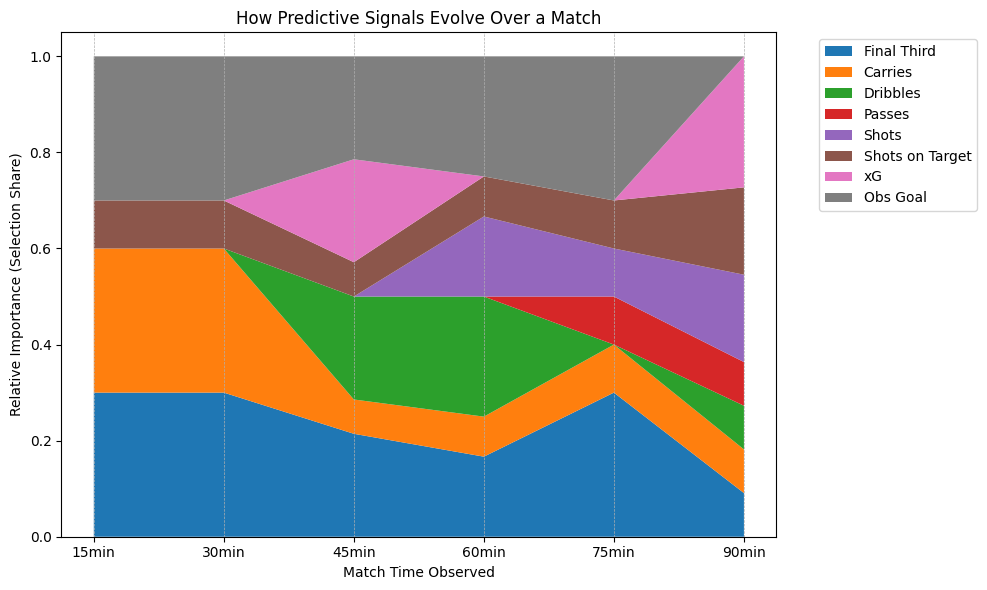

In [38]:
feature_count_pivot = (
    stepwise_long
    .groupby(["dataset", "feature"])
    .size()
    .reset_index(name="count")
    .pivot(index="feature", columns="dataset", values="count")
    .fillna(0)
)

display(feature_count_pivot)

# filter to only the key features 
features_to_keep = ["final_third_diff", "carry_diff", "dribble_diff", "pass_diff", "shot_diff", "sot_diff", "xg_diff", "goal_diff_timebucket"]
# features_to_keep = ["final_third_diff", "carry_diff", "dribble_diff", "pass_diff", "shot_diff", "sot_diff"]

feature_count_filtered = feature_count_pivot.loc[features_to_keep].copy()

feature_label_map = {
    "final_third_diff": "Final Third",
    "carry_diff": "Carries",
    "dribble_diff": "Dribbles",
    "pass_diff": "Passes",
    "shot_diff": "Shots",
    "sot_diff": "Shots on Target",
    "xg_diff": "xG",
    "goal_diff_timebucket": "Obs Goal"
}

# -----------------------------
# normalize counts (due to xG and GDTB forced exclusion)
# -----------------------------
# define availabillty rules
def feature_available(feature, dataset):
    if feature == "xg_diff":
        return 1 / 3
    if feature == "goal_diff_timebucket":
        if dataset == "90min":
            return 0
        return 2 / 3
    return 1.0

# adjust counts
feature_count_adjusted = feature_count_filtered.copy()
for col in feature_count_adjusted.columns:
    for feature in feature_count_adjusted.index:
        avail_ratio = feature_available(feature, col)
        if avail_ratio > 0:
            feature_count_adjusted.loc[feature, col] = (feature_count_adjusted.loc[feature, col] / avail_ratio)
        else:
            feature_count_adjusted.loc[feature, col] = 0

# normalize so each column sums to 1
feature_count_norm = feature_count_adjusted.div(feature_count_adjusted.sum(axis=0), axis=1)

# Rename for clarity
feature_count_norm.index = [feature_label_map[f] for f in feature_count_norm.index]

# -----------------------------
# Plot
# -----------------------------
x_labels = ["15min", "30min", "45min", "60min", "75min", "90min"]
x_numeric = np.array([15, 30, 45, 60, 75, 90])

plt.figure(figsize=(10, 6))

plt.stackplot(
    x_numeric,
    feature_count_norm.values,
    labels=feature_count_norm.index
)

plt.xticks(x_numeric, x_labels)
plt.xlabel("Match Time Observed")
plt.ylabel("Relative Importance (Selection Share)")
plt.title("How Predictive Signals Evolve Over a Match")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1))
plt.grid(axis="x", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "Images" / "how_predictive_signals_evolve_over_a_match.png", dpi=300, bbox_inches='tight')
plt.show()

dataset,15min,30min,45min,60min,75min,90min
feature,,,,,,
carry_diff,4.0,4.0,2.0,2.0,2.0,2.0
dribble_diff,0.0,0.0,4.0,4.0,0.0,2.0
final_third_diff,4.0,4.0,4.0,2.0,4.0,2.0
goal_diff_timebucket,2.0,2.0,2.0,2.0,2.0,0.0
pass_complete_diff,0.0,0.0,2.0,0.0,2.0,2.0
pass_completion_rate,0.0,0.0,0.0,0.0,0.0,2.0
pass_diff,0.0,0.0,0.0,0.0,2.0,2.0
shot_diff,0.0,0.0,0.0,2.0,2.0,2.0
sot_diff,2.0,2.0,2.0,2.0,2.0,2.0


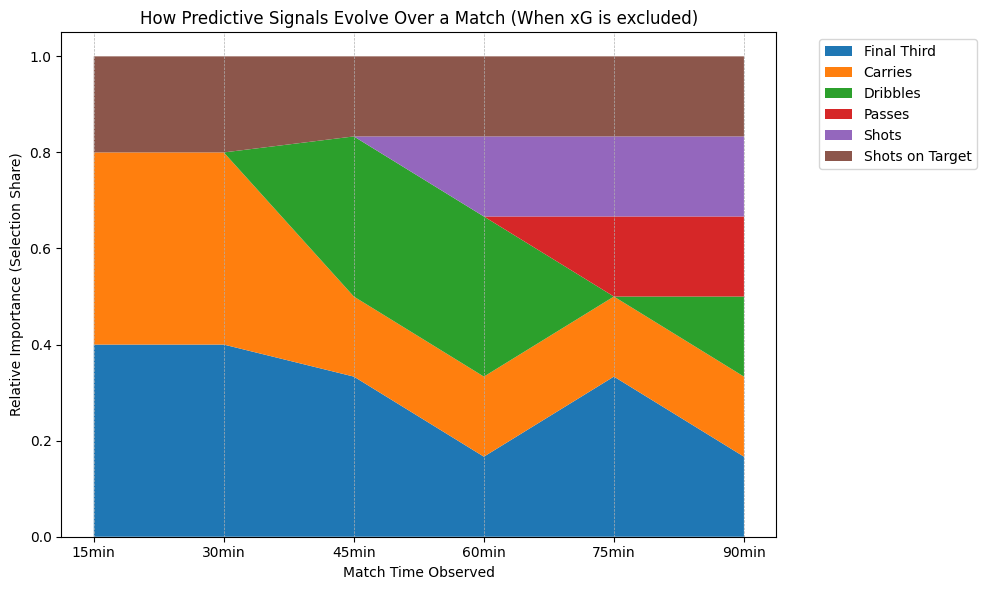

In [39]:
stepwise_long_noxG = stepwise_long[stepwise_long['feature_set'] != 'features'].copy()

feature_count_pivot = (
    stepwise_long_noxG
    .groupby(["dataset", "feature"])
    .size()
    .reset_index(name="count")
    .pivot(index="feature", columns="dataset", values="count")
    .fillna(0)
)

display(feature_count_pivot)

# filter to only the key features 
features_to_keep = ["final_third_diff", "carry_diff", "dribble_diff", "pass_diff", "shot_diff", "sot_diff"]
# features_to_keep = ["final_third_diff", "carry_diff", "dribble_diff", "pass_diff", "shot_diff", "sot_diff"]

feature_count_filtered = feature_count_pivot.loc[features_to_keep].copy()

# -----------------------------
# normalize counts (due to xG and GDTB forced exclusion)
# -----------------------------
# define availabillty rules
def feature_available(feature, dataset):
    if feature == "goal_diff_timebucket":
        if dataset == "90min":
            return 0
        return 1/2
    return 1.0

# adjust counts
feature_count_adjusted = feature_count_filtered.copy()
for col in feature_count_adjusted.columns:
    for feature in feature_count_adjusted.index:
        avail_ratio = feature_available(feature, col)
        if avail_ratio > 0:
            feature_count_adjusted.loc[feature, col] = (feature_count_adjusted.loc[feature, col] / avail_ratio)
        else:
            feature_count_adjusted.loc[feature, col] = 0

# normalize so each column sums to 1
feature_count_norm = feature_count_adjusted.div(feature_count_adjusted.sum(axis=0), axis=1)

# Rename for clarity
feature_count_norm.index = [feature_label_map[f] for f in feature_count_norm.index]

# -----------------------------
# Plot
# -----------------------------
x_labels = ["15min", "30min", "45min", "60min", "75min", "90min"]
x_numeric = np.array([15, 30, 45, 60, 75, 90])

plt.figure(figsize=(10, 6))

plt.stackplot(
    x_numeric,
    feature_count_norm.values,
    labels=feature_count_norm.index
)

plt.xticks(x_numeric, x_labels)
plt.xlabel("Match Time Observed")
plt.ylabel("Relative Importance (Selection Share)")
plt.title("How Predictive Signals Evolve Over a Match (When xG is excluded)")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1))
plt.grid(axis="x", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

In [40]:
feature_count_norm

dataset,15min,30min,45min,60min,75min,90min
Final Third,0.4,0.4,0.333333,0.166667,0.333333,0.166667
Carries,0.4,0.4,0.166667,0.166667,0.166667,0.166667
Dribbles,0.0,0.0,0.333333,0.333333,0.000000,0.166667
Passes,0.0,0.0,0.000000,0.000000,0.166667,0.166667
Shots,0.0,0.0,0.000000,0.166667,0.166667,0.166667
Shots on Target,0.2,0.2,0.166667,0.166667,0.166667,0.166667


In [41]:
stepwise_results_table["feature_set_sorted"] = stepwise_results_table["selected_features"].apply(lambda x: tuple(sorted(x)))
n_unique_sets = stepwise_results_table["feature_set_sorted"].nunique()
# print("Number of unique selected feature sets:", n_unique_sets)
unique_sets = stepwise_results_table["feature_set_sorted"].unique()

for i, s in enumerate(unique_sets, 1):
    print(f"{i}: {list(s)}")
feature_set_counts = (
    stepwise_results_table["feature_set_sorted"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "feature_set", "feature_set_sorted": "count"})
)

display(feature_set_counts)

1: ['carry_diff', 'final_third_diff', 'goal_diff_timebucket']
2: ['dribble_diff', 'final_third_diff', 'goal_diff_timebucket', 'pass_complete_diff', 'xg_diff']
3: ['dribble_diff', 'final_third_diff', 'goal_diff_timebucket', 'shot_diff']
4: ['final_third_diff', 'goal_diff_timebucket']
5: ['shot_diff', 'sot_diff', 'xg_diff']
6: ['dribble_diff', 'final_third_diff', 'goal_diff_timebucket', 'pass_complete_diff']
7: ['carry_diff', 'dribble_diff', 'final_third_diff', 'pass_complete_diff', 'pass_completion_rate', 'pass_diff', 'shot_diff', 'sot_diff']
8: ['carry_diff', 'final_third_diff', 'sot_diff']
9: ['carry_diff', 'dribble_diff', 'final_third_diff', 'sot_diff']
10: ['carry_diff', 'dribble_diff', 'sot_diff']
11: ['carry_diff', 'final_third_diff', 'pass_complete_diff', 'pass_diff', 'shot_diff', 'sot_diff']
12: ['carry_diff', 'final_third_diff', 'goal_diff_timebucket', 'year']
13: ['dribble_diff', 'final_third_diff', 'goal_diff_timebucket', 'pass_complete_diff', 'xg_diff', 'year']
14: ['dribble

,count,count
0,"(carry_diff, final_third_diff, goal_diff_timebucket)",4
1,"(carry_diff, final_third_diff, goal_diff_timebucket, year)",4
2,"(dribble_diff, final_third_diff, goal_diff_timebucket, shot_diff)",2
3,"(dribble_diff, final_third_diff, goal_diff_timebucket, shot_diff, year)",2
4,"(carry_diff, final_third_diff, sot_diff, year)",2
5,"(carry_diff, final_third_diff, sot_diff)",2
6,"(final_third_diff, goal_diff_timebucket, year)",2
7,"(final_third_diff, goal_diff_timebucket)",2
8,"(carry_diff, dribble_diff, sot_diff, year)",1
9,"(carry_diff, dribble_diff, final_third_diff, sot_diff, year)",1


## Logistic Regression Using BIC Forward Search Selected Features
---

In [42]:
# === RUN GROUPED CV ===
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.metrics import accuracy_score,log_loss,roc_auc_score,brier_score_loss

def cross_validate_model(
    train_df,
    feature_cols,
    model,
    target_col="win",
    group_col="match_id",
    n_splits=5,
    prob_threshold=0.5
):
    """
    Cross-validate a binary classification model using grouped folds.

    Designed for the soccer dataset where multiple rows may come from the same match
    (e.g., both teams, multiple time buckets). Grouping on match_id prevents leakage
    across folds.

    Parameters
    ----------
    train_df : Input dataframe
    feature_cols : (list[str]) Predictor column names
    model : Model supporting fit() and predict_proba()
    target_col : (default="win") Binary target column (Win=1, Loss=0, Draw=None/NaN)
    group_col : (default="match_id") Grouping column for CV; should usually be match_id
    n_splits : (default=5) Number of GroupKFold splits
    prob_threshold : (default=0.5) Threshold for converting probabilities to class labels

    Returns
    -------
    dict : Mean and standard deviation of CV metrics
    """
    # ----------------------------------------
    # Drop rows with missing target (e.g., draws)
    # ----------------------------------------
    model_df = train_df.loc[train_df[target_col].notna()].copy()

    X_train = model_df[feature_cols].copy()
    y_train = model_df[target_col].astype(int).copy()
    groups_train = model_df[group_col].copy()

    cv = GroupKFold(n_splits=n_splits)

    acc_scores = []
    logloss_scores = []
    auc_scores = []
    brier_scores = []

    # ----------------------------------------
    # Run grouped CV
    # ----------------------------------------
    for tr_idx, val_idx in cv.split(X_train, y_train, groups_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        fold_model = clone(model)
        fold_model.fit(X_tr, y_tr)

        probs = fold_model.predict_proba(X_val)[:, 1]
        preds = (probs >= prob_threshold).astype(int)

        acc_scores.append(accuracy_score(y_val, preds))
        logloss_scores.append(log_loss(y_val, probs))
        auc_scores.append(roc_auc_score(y_val, probs))
        brier_scores.append(brier_score_loss(y_val, probs))

    # ----------------------------------------
    # Aggregate results
    # ----------------------------------------
    cv_results = {
        "CV_Accuracy": round(float(np.mean(acc_scores)), 4),
        "CV_LogLoss": round(float(np.mean(logloss_scores)), 4),
        "CV_AUC": round(float(np.mean(auc_scores)), 4),
        "CV_BrierScore": round(float(np.mean(brier_scores)), 4),
        "CV_Accuracy_Std": round(float(np.std(acc_scores)), 4),
        "CV_LogLoss_Std": round(float(np.std(logloss_scores)), 4),
        "CV_AUC_Std": round(float(np.std(auc_scores)), 4),
        "CV_BrierScore_Std": round(float(np.std(brier_scores)), 4),
    }

    return cv_results

In [43]:
### update_model_scores() ###
def update_model_scores(
    model_name,
    features,
    model,
    cv_results,
    scores_df=None,
    train_total_minutes=None,
    group_col="match_id",
    notes=None
):
    """
    Store one model's cross-validation results in a comparison table.
    """

    # extract only the most relevant model hyperparameters
    important_params = ["penalty"]
    filtered_params = {
        k: v for k, v in model.get_params().items()
        if k in important_params
    }

    # convert features list to readable string
    feature_string = ", ".join(features)

    new_row = pd.DataFrame({
        "Model": [model_name],
        "Num Features": [len(features)],
        "Features": [feature_string],
        "Model Class": [type(model).__name__],
        "Model Params": [filtered_params],
        "Train Total Minutes": [train_total_minutes],
        "Group Column": [group_col],
        "Notes": [notes],
        "CV_Accuracy": [cv_results["CV_Accuracy"]],
        "CV_LogLoss": [cv_results["CV_LogLoss"]],
        "CV_AUC": [cv_results["CV_AUC"]],
        "CV_BrierScore": [cv_results["CV_BrierScore"]],
        "CV_Accuracy_Std": [cv_results["CV_Accuracy_Std"]],
        "CV_LogLoss_Std": [cv_results["CV_LogLoss_Std"]],
        "CV_AUC_Std": [cv_results["CV_AUC_Std"]],
        "CV_BrierScore_Std": [cv_results["CV_BrierScore_Std"]],
    })

    if scores_df is None:
        return new_row

    # replace any existing row with the same model name
    scores_df = scores_df[scores_df["Model"] != model_name]
    scores_df = pd.concat([scores_df, new_row], ignore_index=True)

    return scores_df

In [44]:
unique_sets

array([('carry_diff', 'final_third_diff', 'goal_diff_timebucket'),
       ('dribble_diff', 'final_third_diff', 'goal_diff_timebucket', 'pass_complete_diff', 'xg_diff'),
       ('dribble_diff', 'final_third_diff', 'goal_diff_timebucket', 'shot_diff'),
       ('final_third_diff', 'goal_diff_timebucket'),
       ('shot_diff', 'sot_diff', 'xg_diff'),
       ('dribble_diff', 'final_third_diff', 'goal_diff_timebucket', 'pass_complete_diff'),
       ('carry_diff', 'dribble_diff', 'final_third_diff', 'pass_complete_diff', 'pass_completion_rate', 'pass_diff', 'shot_diff', 'sot_diff'),
       ('carry_diff', 'final_third_diff', 'sot_diff'),
       ('carry_diff', 'dribble_diff', 'final_third_diff', 'sot_diff'),
       ('carry_diff', 'dribble_diff', 'sot_diff'),
       ('carry_diff', 'final_third_diff', 'pass_complete_diff', 'pass_diff', 'shot_diff', 'sot_diff'),
       ('carry_diff', 'final_third_diff', 'goal_diff_timebucket', 'year'),
       ('dribble_diff', 'final_third_diff', 'goal_diff_timebuc

In [45]:
# create canonical sorted tuples
stepwise_results_table["feature_set_sorted"] = stepwise_results_table["selected_features"].apply(
    lambda x: tuple(sorted(x))
)

# get unique feature sets
unique_sets = stepwise_results_table["feature_set_sorted"].unique()

# build dict for modeling loop
feature_sets = {
    f"featset_{i}": list(s)
    for i, s in enumerate(unique_sets, start=1)
}

timebucket_param_grid = {
    "train_total_minutes": [15, 30, 45, 60, 75, 90],
    "feature_set_name": list(feature_sets.keys()),
}

# results holder
model_scores = None

# track already-run combinations to avoid duplicates
seen_combos = set()

print("Starting LogReg model comparison...")

for i, params in enumerate(ParameterGrid(timebucket_param_grid), start=1):
    
    train_bucket = params["train_total_minutes"]
    feature_set_name = params["feature_set_name"]
    # selected_features = feature_sets[feature_set_name]
    selected_features = feature_sets[feature_set_name].copy()

    # do not allow models on 90min dataset to use goal_diff_timebucket
    if train_bucket == 90:
        selected_features = [f for f in selected_features if f != "goal_diff_timebucket"]
    # skip empty feature sets just in case
    if len(selected_features) == 0:
        continue

    # skip duplicate feature combinations created by removing goal_diff_timebucket
    combo_key = (train_bucket, tuple(sorted(selected_features)))
    if combo_key in seen_combos:
        continue
    seen_combos.add(combo_key)
    
    model_name = f"LogReg | {train_bucket}min | {feature_set_name}"
    df_bucket = df_all_buckets[df_all_buckets["total_minutes"] == train_bucket].copy()    
    model = LogisticRegression(max_iter=1000)
    
    cv_results = cross_validate_model(train_df=df_bucket, feature_cols=selected_features, model=model)

    model_scores = update_model_scores(model_name=model_name, features=selected_features, model=model, cv_results=cv_results, 
                                       scores_df=model_scores, train_total_minutes=train_bucket,notes=f"feature_set={feature_set_name}")

    if i % 5 == 0:
        print(f"{i} models complete")

print("LogReg model comparison complete!")

display(model_scores
    .sort_values(["CV_LogLoss", "CV_BrierScore", "CV_AUC", "CV_Accuracy"], ascending=[True, True, False, False])
    .reset_index(drop=True))

Starting LogReg model comparison...
5 models complete
10 models complete
15 models complete
20 models complete
25 models complete
30 models complete
35 models complete
40 models complete
45 models complete
50 models complete
55 models complete
60 models complete
65 models complete
70 models complete
75 models complete
80 models complete
85 models complete
90 models complete
95 models complete
100 models complete
105 models complete
110 models complete
115 models complete
120 models complete
125 models complete
130 models complete
LogReg model comparison complete!


,Model,Num Features,Features,Model Class,Model Params,Train Total Minutes,Group Column,Notes,CV_Accuracy,CV_LogLoss,CV_AUC,CV_BrierScore,CV_Accuracy_Std,CV_LogLoss_Std,CV_AUC_Std,CV_BrierScore_Std
0,LogReg | 75min | featset_3,4,"dribble_diff, final_third_diff, goal_diff_timebucket, shot_diff",LogisticRegression,{'penalty': 'l2'},75,match_id,feature_set=featset_3,0.9281,0.1671,0.9827,0.0504,0.0108,0.0177,0.0037,0.0059
1,LogReg | 75min | featset_14,5,"dribble_diff, final_third_diff, goal_diff_timebucket, shot_diff, year",LogisticRegression,{'penalty': 'l2'},75,match_id,feature_set=featset_14,0.9281,0.1671,0.9827,0.0504,0.0108,0.0177,0.0037,0.0058
2,LogReg | 75min | featset_4,2,"final_third_diff, goal_diff_timebucket",LogisticRegression,{'penalty': 'l2'},75,match_id,feature_set=featset_4,0.9253,0.1680,0.9826,0.0507,0.0105,0.0179,0.0036,0.0058
3,LogReg | 75min | featset_15,3,"final_third_diff, goal_diff_timebucket, year",LogisticRegression,{'penalty': 'l2'},75,match_id,feature_set=featset_15,0.9253,0.1680,0.9826,0.0507,0.0105,0.0179,0.0036,0.0058
4,LogReg | 75min | featset_1,3,"carry_diff, final_third_diff, goal_diff_timebucket",LogisticRegression,{'penalty': 'l2'},75,match_id,feature_set=featset_1,0.9217,0.1685,0.9823,0.0510,0.0132,0.0187,0.0040,0.0061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,LogReg | 90min | featset_17,4,"dribble_diff, final_third_diff, pass_complete_diff, year",LogisticRegression,{'penalty': 'l2'},90,match_id,feature_set=featset_17,0.6129,0.6347,0.6842,0.2228,0.0144,0.0119,0.0225,0.0057
128,LogReg | 90min | featset_12,3,"carry_diff, final_third_diff, year",LogisticRegression,{'penalty': 'l2'},90,match_id,feature_set=featset_12,0.6205,0.6371,0.6806,0.2238,0.0255,0.0141,0.0277,0.0068
129,LogReg | 90min | featset_1,2,"carry_diff, final_third_diff",LogisticRegression,{'penalty': 'l2'},90,match_id,feature_set=featset_1,0.6202,0.6371,0.6806,0.2238,0.0259,0.0141,0.0277,0.0068
130,LogReg | 90min | featset_4,1,final_third_diff,LogisticRegression,{'penalty': 'l2'},90,match_id,feature_set=featset_4,0.5983,0.6551,0.6510,0.2316,0.0271,0.0120,0.0313,0.0059


In [46]:
train_bucket = 90
feature_set_name = "Kriti"

# selected_features = feature_sets[feature_set_name]
selected_features = ['xg_diff', 'sot_diff', 'shot_diff', 'pressure_diff',
                'carry_diff', 'pass_diff', 'final_third_diff']

model_name = f"LogReg | {train_bucket}min | {feature_set_name}"
df_bucket = df_all_buckets[df_all_buckets["total_minutes"] == train_bucket].copy()    
model = LogisticRegression(max_iter=1000)

cv_results = cross_validate_model(train_df=df_bucket, feature_cols=selected_features, model=model)
cv_results

{'CV_Accuracy': 0.8369,
 'CV_LogLoss': 0.3616,
 'CV_AUC': 0.9179,
 'CV_BrierScore': 0.1156,
 'CV_Accuracy_Std': 0.0078,
 'CV_LogLoss_Std': 0.0116,
 'CV_AUC_Std': 0.006,
 'CV_BrierScore_Std': 0.0049}

## Results & Interpretation
---

,Train Total Minutes,Model,Num Features,Features,Features Short,CV_Accuracy,CV_LogLoss,CV_AUC,CV_BrierScore,Feature Label
0,15,LogReg | 15min | featset_1,3,"carry_diff, final_third_diff, goal_diff_timebucket","carry diff, final 3rd diff, obs. goal diff",0.7261,0.5418,0.8007,0.1823,"carry diff,\nfinal 3rd diff,\nobs. goal diff"
1,30,LogReg | 30min | featset_1,3,"carry_diff, final_third_diff, goal_diff_timebucket","carry diff, final 3rd diff, obs. goal diff",0.7751,0.4744,0.8540,0.1556,"carry diff,\nfinal 3rd diff,\nobs. goal diff"
2,45,LogReg | 45min | featset_2,5,"dribble_diff, final_third_diff, goal_diff_timebucket, pass_complete_diff, xg_diff","drib. diff, final 3rd diff, obs. goal diff, pass comp. diff, xG diff",0.8163,0.3798,0.9084,0.1222,"drib. diff,\nfinal 3rd diff,\nobs. goal diff,\npass comp. diff,\nxG diff"
3,60,LogReg | 60min | featset_3,4,"dribble_diff, final_third_diff, goal_diff_timebucket, shot_diff","drib. diff, final 3rd diff, obs. goal diff, shot diff",0.8818,0.2714,0.9547,0.0834,"drib. diff,\nfinal 3rd diff,\nobs. goal diff,\nshot diff"
4,75,LogReg | 75min | featset_3,4,"dribble_diff, final_third_diff, goal_diff_timebucket, shot_diff","drib. diff, final 3rd diff, obs. goal diff, shot diff",0.9281,0.1671,0.9827,0.0504,"drib. diff,\nfinal 3rd diff,\nobs. goal diff,\nshot diff"
5,90,LogReg | 90min | featset_5,3,"shot_diff, sot_diff, xg_diff","shot diff, SOT diff, xG diff",0.8397,0.3677,0.9149,0.1175,"shot diff,\nSOT diff,\nxG diff"


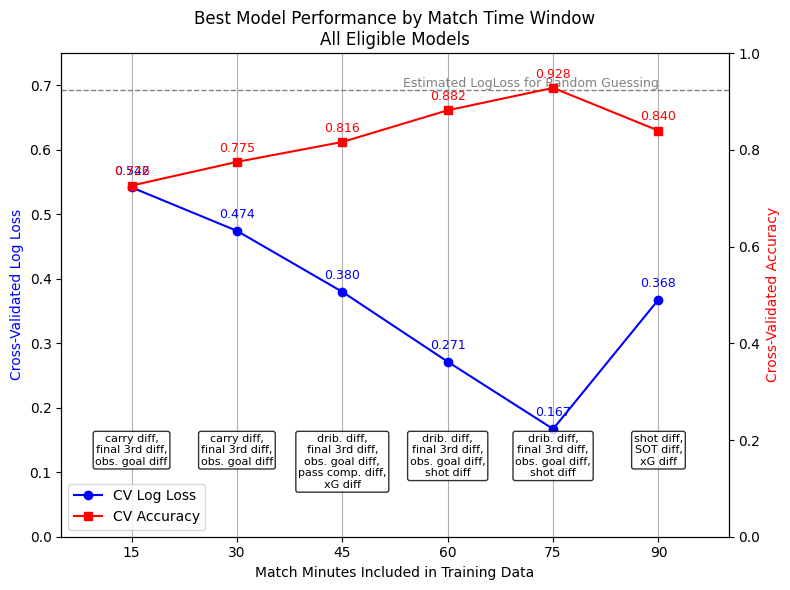

,Train Total Minutes,Model,Num Features,Features,Features Short,CV_Accuracy,CV_LogLoss,CV_AUC,CV_BrierScore,Feature Label
0,15,LogReg | 15min | featset_1,3,"carry_diff, final_third_diff, goal_diff_timebucket","carry diff, final 3rd diff, obs. goal diff",0.7261,0.5418,0.8007,0.1823,"carry diff,\nfinal 3rd diff,\nobs. goal diff"
1,30,LogReg | 30min | featset_1,3,"carry_diff, final_third_diff, goal_diff_timebucket","carry diff, final 3rd diff, obs. goal diff",0.7751,0.4744,0.8540,0.1556,"carry diff,\nfinal 3rd diff,\nobs. goal diff"
2,45,LogReg | 45min | featset_6,4,"dribble_diff, final_third_diff, goal_diff_timebucket, pass_complete_diff","drib. diff, final 3rd diff, obs. goal diff, pass comp. diff",0.8209,0.3811,0.9077,0.1228,"drib. diff,\nfinal 3rd diff,\nobs. goal diff,\npass comp. diff"
3,60,LogReg | 60min | featset_3,4,"dribble_diff, final_third_diff, goal_diff_timebucket, shot_diff","drib. diff, final 3rd diff, obs. goal diff, shot diff",0.8818,0.2714,0.9547,0.0834,"drib. diff,\nfinal 3rd diff,\nobs. goal diff,\nshot diff"
4,75,LogReg | 75min | featset_3,4,"dribble_diff, final_third_diff, goal_diff_timebucket, shot_diff","drib. diff, final 3rd diff, obs. goal diff, shot diff",0.9281,0.1671,0.9827,0.0504,"drib. diff,\nfinal 3rd diff,\nobs. goal diff,\nshot diff"
5,90,LogReg | 90min | featset_11,6,"carry_diff, final_third_diff, pass_complete_diff, pass_diff, shot_diff, sot_diff","carry diff, final 3rd diff, pass comp. diff, pass diff, shot diff, SOT diff",0.8071,0.4149,0.8905,0.1346,"carry diff,\nfinal 3rd diff,\npass comp. diff,\npass diff,\nshot diff,\nSOT diff"


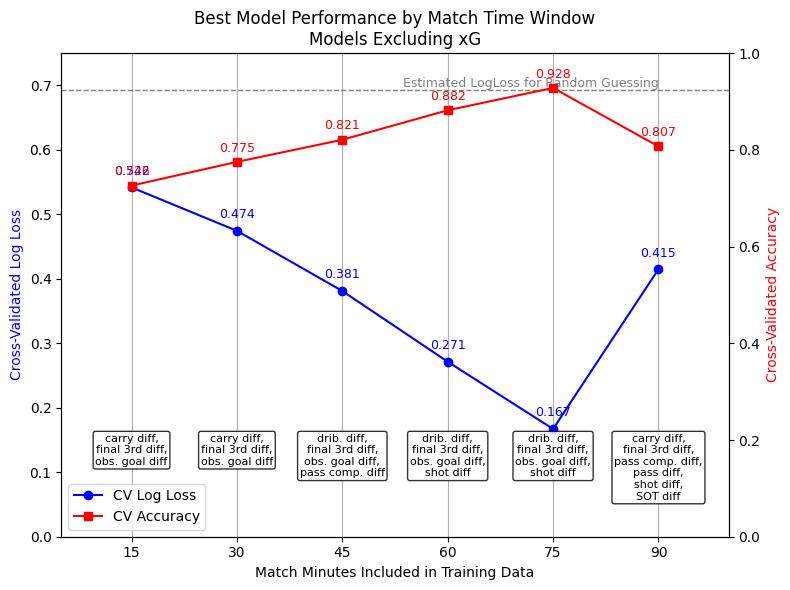

,Train Total Minutes,Model,Num Features,Features,Features Short,CV_Accuracy,CV_LogLoss,CV_AUC,CV_BrierScore,Feature Label
0,15,LogReg | 15min | featset_8,3,"carry_diff, final_third_diff, sot_diff","carry diff, final 3rd diff, SOT diff",0.7013,0.5733,0.7710,0.1949,"carry diff,\nfinal 3rd diff,\nSOT diff"
1,30,LogReg | 30min | featset_11,6,"carry_diff, final_third_diff, pass_complete_diff, pass_diff, shot_diff, sot_diff","carry diff, final 3rd diff, pass comp. diff, pass diff, shot diff, SOT diff",0.7233,0.5410,0.8010,0.1819,"carry diff,\nfinal 3rd diff,\npass comp. diff,\npass diff,\nshot diff,\nSOT diff"
2,45,LogReg | 45min | featset_18,9,"carry_diff, dribble_diff, final_third_diff, pass_complete_diff, pass_completion_rate, pass_diff, shot_diff, sot_diff, year","carry diff, drib. diff, final 3rd diff, pass comp. diff, pass comp. %, pass diff, shot diff, SOT diff, year",0.7467,0.5122,0.8254,0.1704,"carry diff,\ndrib. diff,\nfinal 3rd diff,\npass comp. diff,\npass comp. %,\npass diff,\nshot diff,\nSOT diff,\nyear"
3,60,LogReg | 60min | featset_7,8,"carry_diff, dribble_diff, final_third_diff, pass_complete_diff, pass_completion_rate, pass_diff, shot_diff, sot_diff","carry diff, drib. diff, final 3rd diff, pass comp. diff, pass comp. %, pass diff, shot diff, SOT diff",0.7639,0.4844,0.8468,0.1598,"carry diff,\ndrib. diff,\nfinal 3rd diff,\npass comp. diff,\npass comp. %,\npass diff,\nshot diff,\nSOT diff"
4,75,LogReg | 75min | featset_11,6,"carry_diff, final_third_diff, pass_complete_diff, pass_diff, shot_diff, sot_diff","carry diff, final 3rd diff, pass comp. diff, pass diff, shot diff, SOT diff",0.7737,0.4688,0.8565,0.1544,"carry diff,\nfinal 3rd diff,\npass comp. diff,\npass diff,\nshot diff,\nSOT diff"
5,90,LogReg | 90min | featset_11,6,"carry_diff, final_third_diff, pass_complete_diff, pass_diff, shot_diff, sot_diff","carry diff, final 3rd diff, pass comp. diff, pass diff, shot diff, SOT diff",0.8071,0.4149,0.8905,0.1346,"carry diff,\nfinal 3rd diff,\npass comp. diff,\npass diff,\nshot diff,\nSOT diff"


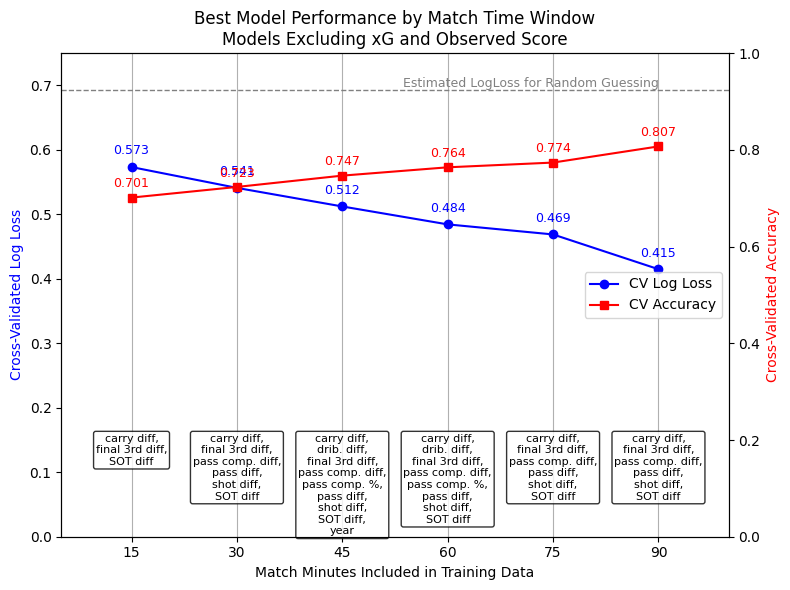

In [47]:
# -----------------------------
# 1. Base copy + parse minutes
# -----------------------------
results = model_scores.copy()

results["Train Total Minutes"] = (
    results["Model"]
    .str.extract(r"\|\s*(\d+)min\s*\|")[0]
    .astype(int)
)

# -----------------------------
# 2. Shorten feature names
# -----------------------------
feature_name_map = {
    "goal_diff_timebucket": "obs. goal diff",
    "final_third_diff": "final 3rd diff",
    "pass_complete_diff": "pass comp. diff",
    "pass_completion_rate": "pass comp. %",
    "carry_diff": "carry diff",
    "dribble_diff": "drib. diff",
    "shot_diff": "shot diff",
    "sot_diff": "SOT diff",
    "xg_diff": "xG diff",
    "pass_diff": "pass diff",
    "year": "year"
}

def shorten_feature_list(feature_string: str) -> str:
    feats = [f.strip() for f in feature_string.split(",")]
    short_feats = [feature_name_map.get(f, f) for f in feats]
    return ", ".join(short_feats)

results["Features Short"] = results["Features"].apply(shorten_feature_list)

# -----------------------------
# 3. Keep only needed columns
# -----------------------------
cols_to_keep = ["Model","Train Total Minutes", "Num Features", "Features", 
                "Features Short", "CV_Accuracy", "CV_LogLoss", "CV_AUC", "CV_BrierScore"]

results_clean = results[cols_to_keep].copy()

# -----------------------------
# 4. Helper functions
# -----------------------------
metric_sort_cols = ["CV_LogLoss", "CV_BrierScore", "CV_AUC", "CV_Accuracy"]
metric_sort_ascending = [True, True, False, False]
metric_cols = ["CV_Accuracy", "CV_LogLoss", "CV_AUC", "CV_BrierScore"]

def contains_feature(feature_string: str, feature_name: str) -> bool:
    feats = [f.strip() for f in feature_string.split(",")]
    return feature_name in feats

def wrap_feature_label(text: str, max_items_per_line: int = 1) -> str:
    items = [x.strip() for x in text.split(",")]
    lines = []
    for i in range(0, len(items), max_items_per_line):
        chunk = items[i:i+max_items_per_line]
        line = ", ".join(chunk)
        if i + max_items_per_line < len(items):
            line += ","
        lines.append(line)
    return "\n".join(lines)

def build_outputs(results_df, scenario_name, save_filename):
    # sort once
    df_sorted = results_df.sort_values(
        metric_sort_cols,
        ascending=metric_sort_ascending
    ).copy()
    
    # -----------------------------
    # Top 3 models per time bucket
    # -----------------------------
    top3_by_bucket = (
        df_sorted
        .groupby("Train Total Minutes", group_keys=False).head(3)
        .sort_values(["Train Total Minutes"] + metric_sort_cols, ascending=[True] + metric_sort_ascending)
        .reset_index(drop=True)
    )
    
    top3_by_bucket_display = top3_by_bucket.copy()
    top3_by_bucket_display[metric_cols] = top3_by_bucket_display[metric_cols].round(4)
    
    # -----------------------------
    # Best model per time bucket
    # -----------------------------
    best_by_bucket = (df_sorted
        .groupby("Train Total Minutes", as_index=False)
        .first()
        .sort_values("Train Total Minutes")
        .reset_index(drop=True))
    
    best_by_bucket["Feature Label"] = best_by_bucket["Features Short"].apply(lambda x: wrap_feature_label(x))
    display(best_by_bucket)
    
    # -----------------------------
    # Dual-axis plot
    # -----------------------------
    fig, ax1 = plt.subplots(figsize=(8, 6))
    
    # Left axis: Log Loss
    line1 = ax1.plot(
        best_by_bucket["Train Total Minutes"],
        best_by_bucket["CV_LogLoss"],
        marker="o",
        label="CV Log Loss",
        color="blue"
    )
    ax1.set_xlabel("Match Minutes Included in Training Data")
    ax1.set_xticks([15, 30, 45, 60, 75, 90])
    ax1.set_ylabel("Cross-Validated Log Loss", color="blue")
    ax1.axhline(0.693, linestyle="--", linewidth=1, color='gray')
    ax1.text(x=best_by_bucket["Train Total Minutes"].max(),y=0.693,s="Estimated LogLoss for Random Guessing",va="bottom",ha="right",fontsize=9,color="gray")
    ax1.set_ylim(0, 0.75)
    ax1.set_xlim(5, 100)
    ax1.grid(True, axis='x')

    # Right axis: Accuracy
    ax2 = ax1.twinx()
    line2 = ax2.plot(
        best_by_bucket["Train Total Minutes"],
        best_by_bucket["CV_Accuracy"],
        marker="s",
        label="CV Accuracy",
        color="red"
    )
    ax2.set_ylabel("Cross-Validated Accuracy", color="red")
    ax2.set_ylim(0, 1)

    # Add Log Loss labels
    for x, y in zip(best_by_bucket["Train Total Minutes"], best_by_bucket["CV_LogLoss"]):
        ax1.text(
            x,
            y + 0.015,  # slight upward offset
            f"{y:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="blue"
        )
    # Add Accuracy labels
    for x, y in zip(best_by_bucket["Train Total Minutes"], best_by_bucket["CV_Accuracy"]):
        ax2.text(
            x,
            y + 0.015,  # slight upward offset
            f"{y:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="red"
        )
    
    # Annotate points with selected features
    y_label_level = 0.16

    for _, row in best_by_bucket.iterrows():
        ax1.text(
            row["Train Total Minutes"],
            y_label_level,
            row["Feature Label"],
            ha="center",
            va="top",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2",facecolor="white",edgecolor="black",alpha=0.8)
        )
    
    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="best")
    
    plt.title(f"Best Model Performance by Match Time Window\n{scenario_name}")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "Images" / save_filename, dpi=300, bbox_inches="tight")
    plt.show()
    
    return top3_by_bucket_display, best_by_bucket

#    As-is (xG allowed, GDTB excluded from 90-min models upstream)
scenario1_df = results_clean.copy()

top3_s1, best_s1 = build_outputs(results_df=scenario1_df, scenario_name="All Eligible Models", save_filename="model_results_all.png")

#    Remove rows using xG
scenario2_df = results_clean[~results_clean["Features"].apply(lambda x: contains_feature(x, "xg_diff"))].copy()
top3_s2, best_s2 = build_outputs(results_df=scenario2_df,scenario_name="Models Excluding xG",save_filename="model_results_no_xg.png")

#    Remove rows using xG or GDTB
scenario3_df = results_clean[~results_clean["Features"].apply(lambda x: contains_feature(x, "xg_diff")) &~results_clean["Features"].apply(lambda x: contains_feature(x, "goal_diff_timebucket"))].copy()

top3_s3, best_s3 = build_outputs(
    results_df=scenario3_df,
    scenario_name="Models Excluding xG and Observed Score",
    save_filename="model_results_no_xg_no_score.png"
)

In [48]:
compare_df = (
    best_s1[["Train Total Minutes", "CV_LogLoss", "CV_Accuracy"]]
    .rename(columns={
        "CV_LogLoss": "logloss_all",
        "CV_Accuracy": "acc_all"
    })
    .merge(
        best_s2[["Train Total Minutes", "CV_LogLoss", "CV_Accuracy"]]
        .rename(columns={
            "CV_LogLoss": "logloss_no_xg",
            "CV_Accuracy": "acc_no_xg"
        }),
        on="Train Total Minutes",
        how="inner"
    )
    .merge(
        best_s3[["Train Total Minutes", "CV_LogLoss", "CV_Accuracy"]]
        .rename(columns={
            "CV_LogLoss": "logloss_no_xg_no_score",
            "CV_Accuracy": "acc_no_xg_no_score"
        }),
        on="Train Total Minutes",
        how="inner"
    )
    .sort_values("Train Total Minutes")
)

display(compare_df.round(4))

compare_df["delta_logloss_no_xg"] = (
    compare_df["logloss_no_xg"] - compare_df["logloss_all"]
)
compare_df["delta_logloss_no_xg_no_score"] = (
    compare_df["logloss_no_xg_no_score"] - compare_df["logloss_all"]
)

display(compare_df.round(4))

,Train Total Minutes,logloss_all,acc_all,logloss_no_xg,acc_no_xg,logloss_no_xg_no_score,acc_no_xg_no_score
0,15,0.5418,0.7261,0.5418,0.7261,0.5733,0.7013
1,30,0.4744,0.7751,0.4744,0.7751,0.5410,0.7233
2,45,0.3798,0.8163,0.3811,0.8209,0.5122,0.7467
3,60,0.2714,0.8818,0.2714,0.8818,0.4844,0.7639
4,75,0.1671,0.9281,0.1671,0.9281,0.4688,0.7737
5,90,0.3677,0.8397,0.4149,0.8071,0.4149,0.8071


,Train Total Minutes,logloss_all,acc_all,logloss_no_xg,acc_no_xg,logloss_no_xg_no_score,acc_no_xg_no_score,delta_logloss_no_xg,delta_logloss_no_xg_no_score
0,15,0.5418,0.7261,0.5418,0.7261,0.5733,0.7013,0.0000,0.0315
1,30,0.4744,0.7751,0.4744,0.7751,0.5410,0.7233,0.0000,0.0666
2,45,0.3798,0.8163,0.3811,0.8209,0.5122,0.7467,0.0013,0.1324
3,60,0.2714,0.8818,0.2714,0.8818,0.4844,0.7639,0.0000,0.2130
4,75,0.1671,0.9281,0.1671,0.9281,0.4688,0.7737,0.0000,0.3017
5,90,0.3677,0.8397,0.4149,0.8071,0.4149,0.8071,0.0472,0.0472


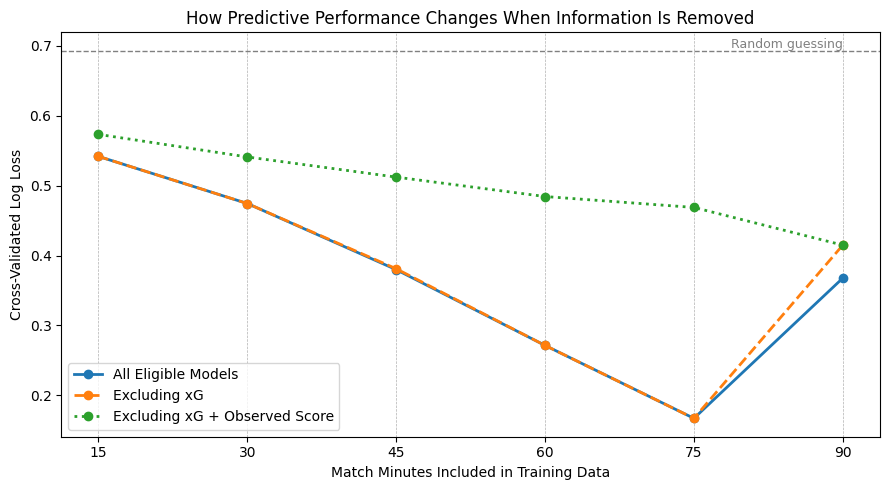

In [49]:
plt.figure(figsize=(9, 5))

plt.plot(
    compare_df["Train Total Minutes"],
    compare_df["logloss_all"],
    marker="o",
    linewidth=2,
    label="All Eligible Models"
)

plt.plot(
    compare_df["Train Total Minutes"],
    compare_df["logloss_no_xg"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Excluding xG"
)

plt.plot(
    compare_df["Train Total Minutes"],
    compare_df["logloss_no_xg_no_score"],
    marker="o",
    linewidth=2,
    linestyle=":",
    label="Excluding xG + Observed Score"
)

plt.axhline(0.693, linestyle="--", linewidth=1, color="gray")
plt.text(
    x=compare_df["Train Total Minutes"].max(),
    y=0.693,
    s="Random guessing",
    ha="right",
    va="bottom",
    fontsize=9,
    color="gray"
)

plt.xticks([15, 30, 45, 60, 75, 90])
plt.xlabel("Match Minutes Included in Training Data")
plt.ylabel("Cross-Validated Log Loss")
plt.title("How Predictive Performance Changes When Information Is Removed")
plt.grid(True, axis="x", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

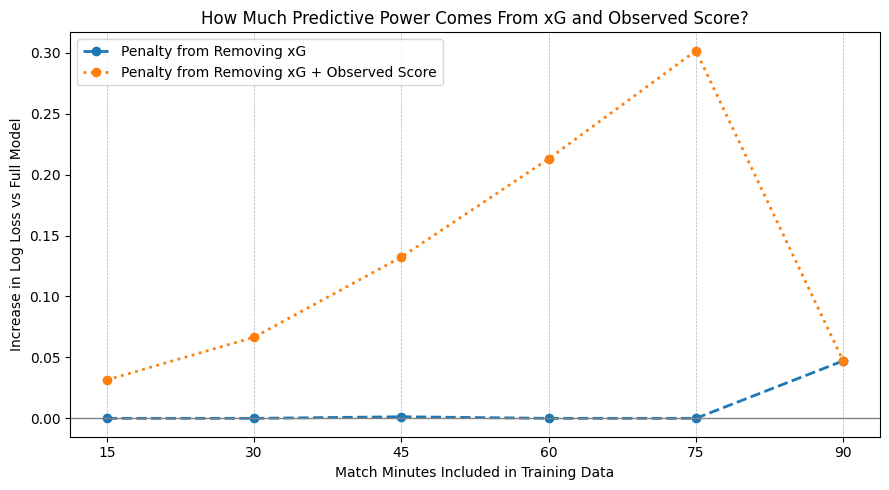

In [50]:
plt.figure(figsize=(9, 5))

plt.plot(
    compare_df["Train Total Minutes"],
    compare_df["delta_logloss_no_xg"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Penalty from Removing xG"
)

plt.plot(
    compare_df["Train Total Minutes"],
    compare_df["delta_logloss_no_xg_no_score"],
    marker="o",
    linewidth=2,
    linestyle=":",
    label="Penalty from Removing xG + Observed Score"
)

plt.axhline(0, linestyle="-", linewidth=1, color="gray")

plt.xticks([15, 30, 45, 60, 75, 90])
plt.xlabel("Match Minutes Included in Training Data")
plt.ylabel("Increase in Log Loss vs Full Model")
plt.title("How Much Predictive Power Comes From xG and Observed Score?")
plt.grid(True, axis="x", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "Images" / "How_much_Predictive_power_comes_from_xG_and_obsScore.png", dpi=300, bbox_inches='tight')

plt.show()